# 04.3 - Missing Values

**Phase:** 04 - Data Analysis & Preparation

**Status:** VERIFIED

---

## 1. What Are We Solving?

Real datasets often have **missing values**. How we handle them matters: dropping too much loses data, imputing incorrectly biases results. This unit covers the types of missingness and imputation strategies.

## 2. Why Does This Matter?

Most ML algorithms can't handle missing values directly. Choosing the right strategy affects model quality. Understanding *why* data is missing (the mechanism) guides the right approach.

## 3. Prerequisites

- Unit 04.1 (EDA)
- Unit 04.2 (Data cleaning)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Detect missing values
- Understand MCAR, MAR, and MNAR
- Choose between dropping and imputing
- Apply mean, median, and mode imputation
- Use scikit-learn's SimpleImputer

## 5. Mental Model

Missingness mechanisms:
- **MCAR** (Missing Completely At Random): missingness unrelated to data.
- **MAR** (Missing At Random): missingness related to observed data.
- **MNAR** (Missing Not At Random): missingness related to the missing value itself.

Strategy: detect -> understand mechanism -> drop or impute.


## 6. Detect Missing Values

First, find where and how much data is missing.


In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200
df = pd.DataFrame({
    "age": np.random.randint(18, 70, n).astype(float),
    "income": np.random.normal(60000, 20000, n),
    "score": np.random.normal(70, 15, n),
})

# Introduce missing values
df.loc[np.random.choice(n, 20, replace=False), "income"] = np.nan
df.loc[np.random.choice(n, 15, replace=False), "score"] = np.nan
df.loc[np.random.choice(n, 10, replace=False), "age"] = np.nan

print("Missing values per column:")
print(df.isnull().sum())
print("\nPercentage missing:")
print(df.isnull().mean() * 100)
print("\nTotal missing:", df.isnull().sum().sum())


Missing values per column:
age       10
income    20
score     15
dtype: int64

Percentage missing:
age        5.0
income    10.0
score      7.5
dtype: float64

Total missing: 45


## 7. Visualize Missingness

A heatmap shows the pattern of missingness.


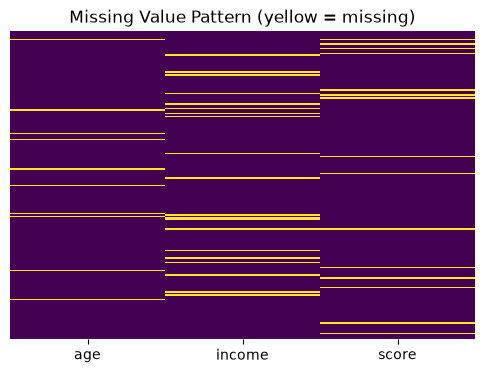

Yellow cells are missing. Random-looking pattern suggests MCAR.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Value Pattern (yellow = missing)")
plt.show()
print("Yellow cells are missing. Random-looking pattern suggests MCAR.")


## 8. Option 1: Drop Missing Values

Dropping is simple but loses data. Only drop when few values are missing.


In [3]:
# Drop rows with any missing value
df_drop = df.dropna()
print(f"Original rows: {len(df)}")
print(f"Rows after dropna: {len(df_drop)}")
print(f"Rows lost: {len(df) - len(df_drop)}")
print("\nDropping loses data - only good when few values are missing.")


Original rows: 200
Rows after dropna: 157
Rows lost: 43

Dropping loses data - only good when few values are missing.


## 9. Option 2: Mean/Median Imputation

Imputation fills missing values with a statistic. **Median** is more robust to outliers than **mean**.


In [4]:
# Mean imputation
df_mean = df.copy()
df_mean["income"] = df_mean["income"].fillna(df_mean["income"].mean())
df_mean["score"] = df_mean["score"].fillna(df_mean["score"].mean())
df_mean["age"] = df_mean["age"].fillna(df_mean["age"].mean())

print("After mean imputation, missing values:")
print(df_mean.isnull().sum())
print("\nMean imputation fills all missing values.")


After mean imputation, missing values:
age       0
income    0
score     0
dtype: int64

Mean imputation fills all missing values.


## 10. Mode Imputation for Categorical

For categorical columns, use the **mode** (most frequent value).


In [5]:
# Mode imputation for a categorical column
df_cat = pd.DataFrame({"color": ["red", "blue", "red", None, "blue", "red", None, "green"]})
print("Before:")
print(df_cat)

mode_val = df_cat["color"].mode()[0]
df_cat["color"] = df_cat["color"].fillna(mode_val)
print("\nAfter mode imputation:")
print(df_cat)
print(f"\nFilled with mode: {mode_val}")


Before:
   color
0    red
1   blue
2    red
3    NaN
4   blue
5    red
6    NaN
7  green

After mode imputation:
   color
0    red
1   blue
2    red
3    red
4   blue
5    red
6    red
7  green

Filled with mode: red


## 11. scikit-learn SimpleImputer

scikit-learn's `SimpleImputer` provides a consistent API and integrates with pipelines.


In [6]:
from sklearn.impute import SimpleImputer

# Median imputer
imputer = SimpleImputer(strategy="median")
df_imp = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("After SimpleImputer (median):")
print(df_imp.isnull().sum())
print("\nNo missing values remain.")


After SimpleImputer (median):
age       0
income    0
score     0
dtype: int64

No missing values remain.


## 12. Missingness Mechanisms

Understanding *why* data is missing guides the strategy.

- **MCAR**: missingness is random - imputation is safe.
- **MAR**: missingness depends on observed data - imputation using other features is better.
- **MNAR**: missingness depends on the missing value itself - imputation can bias results.


In [7]:
# Demonstrate MAR: income missing more often for older people
np.random.seed(5)
n = 300
age = np.random.randint(18, 80, n)
income = 30000 + 500 * age + np.random.normal(0, 5000, n)

# Older people more likely to have missing income (MAR)
missing = (age > 60) & (np.random.random(n) < 0.5)
income_missing = income.copy()
income_missing[missing] = np.nan

df_mar = pd.DataFrame({"age": age, "income": income_missing})
print("Missing income by age group:")
df_mar["age_group"] = pd.cut(df_mar["age"], bins=[0, 40, 60, 100], labels=["young", "middle", "old"])
print(df_mar.groupby("age_group")["income"].apply(lambda s: s.isnull().mean()))
print("\nOlder people have more missing income - this is MAR.")
print("Imputing with the overall mean would bias the estimate.")


Missing income by age group:
age_group
young     0.000000
middle    0.000000
old       0.526316
Name: income, dtype: float64

Older people have more missing income - this is MAR.
Imputing with the overall mean would bias the estimate.


## 13. Failure Case: Wrong Imputation

Imputing with the mean when data is MAR can bias results. Better to use a model that accounts for the relationship (e.g. impute income using age).


In [8]:
# Compare: overall mean vs age-aware imputation for MAR data
overall_mean = df_mar["income"].mean()

# Age-aware: impute using mean income within each age group
df_mar["income_mean"] = df_mar["income"].fillna(overall_mean)
df_mar["income_age"] = df_mar.groupby("age_group")["income"].transform(lambda s: s.fillna(s.mean()))

true_mean = income.mean()
print(f"True mean income: {true_mean:.0f}")
print(f"Overall-mean imputed mean: {df_mar['income_mean'].mean():.0f}")
print(f"Age-aware imputed mean: {df_mar['income_age'].mean():.0f}")
print("\nAge-aware imputation is closer to the true mean for MAR data.")


True mean income: 53348
Overall-mean imputed mean: 51446
Age-aware imputed mean: 53300

Age-aware imputation is closer to the true mean for MAR data.


## 14. Debugging: Common Errors

- **Not detecting missing values**: models fail or silently misbehave.
- **Using mean with outliers**: median is more robust.
- **Ignoring the mechanism**: MAR data needs feature-aware imputation.
- **Imputing before splitting**: causes data leakage (see Unit 04.7).
- **Not checking after imputation**: verify no missing values remain.

## 15. Real-World Considerations

- Impute on training data only, then apply to test data.
- For MAR/MNAR, consider model-based imputation.
- Some models (XGBoost) handle missing values natively.
- Document your imputation strategy.

## 16. Common Mistakes

- Dropping too much data.
- Using mean when median is better.
- Ignoring why data is missing.
- Imputing before train/test split.

## 17. When NOT to Use

- Don't impute when missingness is informative (MNAR) - consider a 'missing' indicator.
- Don't drop when you can impute and data is scarce.
- Don't use simple imputation for complex MAR patterns.

## 18. Challenge

A dataset has 10% missing values in a numeric column with a few outliers. Choose the best imputation strategy and justify it.


In [9]:
# Challenge: choose imputation strategy
np.random.seed(7)
data = np.random.normal(50, 10, 200)
data[0] = 500  # add an outlier
data[np.random.choice(200, 20, replace=False)] = np.nan

df_ch = pd.DataFrame({"value": data})

mean_imp = df_ch["value"].fillna(df_ch["value"].mean())
median_imp = df_ch["value"].fillna(df_ch["value"].median())

print(f"Mean of non-missing: {df_ch['value'].mean():.2f}")
print(f"Median of non-missing: {df_ch['value'].median():.2f}")
print(f"\nMean imputation fills with {mean_imp.mean():.2f}")
print(f"Median imputation fills with {median_imp.mean():.2f}")
print("\nBecause of the outlier (500), the median is more robust.")
print("Median imputation is the better choice here.")


Mean of non-missing: 52.06
Median of non-missing: 49.49

Mean imputation fills with 52.06
Median imputation fills with 51.81

Because of the outlier (500), the median is more robust.
Median imputation is the better choice here.


## 19. Closed-Book Recall

Without looking back:

1. What are MCAR, MAR, and MNAR?
2. When should you drop vs impute?
3. Why is median better than mean with outliers?
4. What is mode imputation for?
5. Why impute on train data only?

## 20. Teach-Back Questions

Explain to another person:

- The difference between MCAR, MAR, and MNAR.
- Why the missingness mechanism matters for imputation.
- When to use mean vs median vs mode imputation.

## 21. Summary

You now understand missing values: how to detect them, the mechanisms (MCAR/MAR/MNAR), and strategies (drop, mean/median/mode imputation, SimpleImputer). You know that the missingness mechanism guides the right approach.

## 22. Further Experiment

- Use `KNNImputer` for feature-aware imputation.
- Add a 'missing' indicator column for MNAR.
- Compare imputation strategies on model performance.

## 23. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: pandas, numpy, matplotlib, seaborn, scikit-learn
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
